<a href="https://colab.research.google.com/github/Meemansha-spec/EDA-with-Pandas/blob/main/Churn_data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
telecom = pd.read_csv('telecom_customer_churn.csv')
df_raw = telecom.copy()

In [ ]:
telecom.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.83,-119.00,2,9,NaN,Yes,42.39,No,Yes,Cable,16.00,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.16,-118.20,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.00,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.65,-117.92,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.00,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.01,-122.12,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.00,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,"1,237.85",0.00,0,361.66,"1,599.51",Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.23,-119.08,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.00,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
print("Number of rows",telecom.shape[0])
print("Number of columns", telecom.shape[1])

Number of rows 7043
Number of columns 38


In [ ]:
telecom.sample(5,random_state = 42)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
185,0301-KOBTQ,Male,50,No,0,Capitola,95010,36.98,-121.95,0,32,NaN,Yes,14.91,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Two Year,Yes,Bank Withdrawal,20.05,614.45,9.73,0,477.12,"1,081.84",Stayed,NaN,NaN
2715,3865-YIOTT,Male,40,Yes,1,San Francisco,94110,37.75,-122.42,1,72,NaN,Yes,11.67,Yes,Yes,Fiber Optic,26.00,Yes,No,Yes,No,Yes,Yes,Yes,Yes,One Year,Yes,Bank Withdrawal,106.10,"7,848.50",0.00,0,840.24,"8,688.74",Stayed,NaN,NaN
3825,5377-NDTOU,Female,26,Yes,0,San Pedro,90732,33.74,-118.31,3,71,Offer A,Yes,9.50,Yes,Yes,Cable,76.00,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,No,Credit Card,91.05,"6,293.75",0.00,0,674.50,"6,968.25",Stayed,NaN,NaN
1807,2637-FKFSY,Female,61,Yes,0,Wasco,93280,35.65,-119.45,2,3,NaN,Yes,2.66,No,Yes,DSL,7.00,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Mailed Check,46.10,130.15,0.00,0,7.98,138.13,Joined,NaN,NaN
132,0224-NIJLP,Male,30,Yes,3,Turlock,95380,37.47,-120.88,1,8,Offer E,Yes,2.87,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Two Year,No,Credit Card,20.15,165.50,0.00,0,22.96,188.46,Stayed,NaN,NaN


## Convert all the column names into lowercase for easy access

In [ ]:
telecom.columns = telecom.columns.str.lower().str.replace(r'\s+', '_', regex=True)

In [ ]:
telecom.columns.tolist()

['customer_id',
 'gender',
 'age',
 'married',
 'number_of_dependents',
 'city',
 'zip_code',
 'latitude',
 'longitude',
 'number_of_referrals',
 'tenure_in_months',
 'offer',
 'phone_service',
 'avg_monthly_long_distance_charges',
 'multiple_lines',
 'internet_service',
 'internet_type',
 'avg_monthly_gb_download',
 'online_security',
 'online_backup',
 'device_protection_plan',
 'premium_tech_support',
 'streaming_tv',
 'streaming_movies',
 'streaming_music',
 'unlimited_data',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charge',
 'total_charges',
 'total_refunds',
 'total_extra_data_charges',
 'total_long_distance_charges',
 'total_revenue',
 'customer_status',
 'churn_category',
 'churn_reason']

In [ ]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [ ]:
telecom.dtypes.value_counts()

,count
object,23
float64,9
int64,6


In [ ]:
dtype_summary = pd.DataFrame({"column_name": telecom.columns,
                              "data_type": telecom.dtypes.astype(str).values})
dtype_summary

,column_name,data_type
0,customer_id,object
1,gender,object
2,age,int64
3,married,object
4,number_of_dependents,int64
5,city,object
6,zip_code,int64
7,latitude,float64
8,longitude,float64
9,number_of_referrals,int64


#### Schema Summary
-  Data type
-  Missing values
-  Unique Values
-  Sample Values

In [ ]:
schema_summary = pd.DataFrame({"column_name": telecom.columns,
                              "data_type": telecom.dtypes.astype(str).values,
                               "non_null_count": telecom.notnull().sum().values,
                               "null_count": telecom.isnull().sum().values,
                               "null_percentage": (telecom.isnull().mean()*100).round(2).values,
                               "unique_values": telecom.nunique().values
})


schema_summary = schema_summary.sort_values(by = "null_percentage",ascending = False).reset_index(drop = True)
schema_summary

,column_name,data_type,non_null_count,null_count,null_percentage,unique_values
0,churn_reason,object,1869,5174,73.46,20
1,churn_category,object,1869,5174,73.46,5
2,offer,object,3166,3877,55.05,5
3,online_backup,object,5517,1526,21.67,2
4,avg_monthly_gb_download,float64,5517,1526,21.67,49
5,online_security,object,5517,1526,21.67,2
6,streaming_movies,object,5517,1526,21.67,2
7,streaming_tv,object,5517,1526,21.67,2
8,unlimited_data,object,5517,1526,21.67,2
9,streaming_music,object,5517,1526,21.67,2


In [ ]:
telecom.duplicated().sum()

np.int64(0)

In [ ]:
# Missing value summary

missing_summary = pd.DataFrame({
    "column_name": telecom.columns,
    "missing_count": telecom.isnull().sum().values,
    "missing_percentage": (telecom.isnull().mean() * 100).round(2).values
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
).reset_index(drop=True)

missing_summary


,column_name,missing_count,missing_percentage
0,churn_category,5174,73.46
1,churn_reason,5174,73.46
2,offer,3877,55.05
3,online_security,1526,21.67
4,online_backup,1526,21.67
5,avg_monthly_gb_download,1526,21.67
6,internet_type,1526,21.67
7,streaming_movies,1526,21.67
8,streaming_tv,1526,21.67
9,device_protection_plan,1526,21.67


#### Seperate Numerical and Categorical Columns

In [ ]:
# Separate numerical and categorical columns

numerical_cols = telecom.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = telecom.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", len(numerical_cols))
print(numerical_cols)

print("\nCategorical Columns:", len(categorical_cols))
print(categorical_cols)

Numerical Columns: 15
['age', 'number_of_dependents', 'zip_code', 'latitude', 'longitude', 'number_of_referrals', 'tenure_in_months', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue']

Categorical Columns: 23
['customer_id', 'gender', 'married', 'city', 'offer', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'customer_status', 'churn_category', 'churn_reason']


In [ ]:
## Numerical columns summary
telecom[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"7,043.00",46.51,16.75,19.00,32.00,46.00,60.00,80.00
number_of_dependents,"7,043.00",0.47,0.96,0.00,0.00,0.00,0.00,9.00
zip_code,"7,043.00","93,486.07","1,856.77","90,001.00","92,101.00","93,518.00","95,329.00","96,150.00"
latitude,"7,043.00",36.20,2.47,32.56,33.99,36.21,38.16,41.96
longitude,"7,043.00",-119.76,2.15,-124.30,-121.79,-119.60,-117.97,-114.19
number_of_referrals,"7,043.00",1.95,3.00,0.00,0.00,0.00,3.00,11.00
tenure_in_months,"7,043.00",32.39,24.54,1.00,9.00,29.00,55.00,72.00
avg_monthly_long_distance_charges,"6,361.00",25.42,14.20,1.01,13.05,25.69,37.68,49.99
avg_monthly_gb_download,"5,517.00",26.19,19.59,2.00,13.00,21.00,30.00,85.00
monthly_charge,"7,043.00",63.60,31.20,-10.00,30.40,70.05,89.75,118.75


In [ ]:
telecom[categorical_cols].describe().T

,count,unique,top,freq
Customer ID,7043,7043,9995-HOTOH,1
Gender,7043,2,Male,3555
Married,7043,2,No,3641
City,7043,1106,Los Angeles,293
Offer,3166,5,Offer B,824
Phone Service,7043,2,Yes,6361
Multiple Lines,6361,2,No,3390
Internet Service,7043,2,Yes,5517
Internet Type,5517,3,Fiber Optic,3035
Online Security,5517,2,No,3498


In [ ]:
target_col = 'customer_status'
telecom[target_col].value_counts().reset_index()

,customer_status,count
0,Stayed,4720
1,Churned,1869
2,Joined,454


In [ ]:
### Customer status percentage distribution
# Customer Status percentage distribution

customer_status_distribution = pd.DataFrame({
    "customer_count": telecom[target_col].value_counts(),
    "percentage": (telecom[target_col].value_counts(normalize=True) * 100).round(2)
})

customer_status_distribution.reset_index()


,customer_status,customer_count,percentage
0,Stayed,4720,67.02
1,Churned,1869,26.54
2,Joined,454,6.45


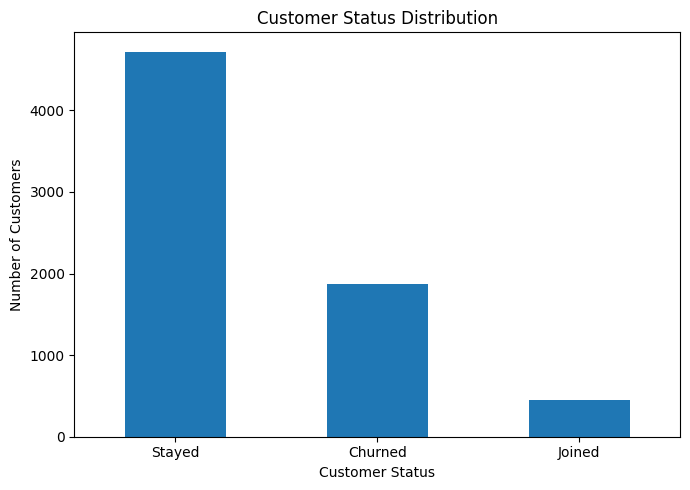

In [ ]:
# Visualize customer status distribution

plt.figure(figsize=(7, 5))
telecom[target_col].value_counts().plot(kind="bar")
plt.title("Customer Status Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Revenue - level - Understanding

In [ ]:
# Revenue overview

revenue_cols = [
    "monthly_charge",
    "total_charges",
    "total_refunds",
    "total_extra_data_charges",
    "total_long_distance_charges",
    "total_revenue"
]

telecom[revenue_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
monthly_charge,"7,043.00",63.60,31.20,-10.00,30.40,70.05,89.75,118.75
total_charges,"7,043.00","2,280.38","2,266.22",18.80,400.15,"1,394.55","3,786.60","8,684.80"
total_refunds,"7,043.00",1.96,7.90,0.00,0.00,0.00,0.00,49.79
total_extra_data_charges,"7,043.00",6.86,25.10,0.00,0.00,0.00,0.00,150.00
total_long_distance_charges,"7,043.00",749.10,846.66,0.00,70.55,401.44,"1,191.10","3,564.72"
total_revenue,"7,043.00","3,034.38","2,865.20",21.36,605.61,"2,108.64","4,801.15","11,979.34"


In [ ]:
# Revenue contribution by customer status

revenue_by_status = telecom.groupby("customer_status")["total_revenue"].sum()
revenue_by_status.reset_index()

,customer_status,total_revenue
0,Churned,"3,684,459.82"
1,Joined,"54,279.75"
2,Stayed,"17,632,392.12"


#### Churn Category Understanding

In [ ]:
telecom['churn_category'].value_counts()

,count
churn_category,
Competitor,841
Dissatisfaction,321
Attitude,314
Price,211
Other,182


In [ ]:
telecom['churn_reason'].value_counts().reset_index()

,churn_reason,count
0,Competitor had better devices,313
1,Competitor made better offer,311
2,Attitude of support person,220
3,Don't know,130
4,Competitor offered more data,117
5,Competitor offered higher download speeds,100
6,Attitude of service provider,94
7,Price too high,78
8,Product dissatisfaction,77
9,Network reliability,72


In [ ]:
telecom['contract'].value_counts()

,count
contract,
Month-to-Month,3610
Two Year,1883
One Year,1550


In [ ]:
# Churn by Contract Type

contract_churn_summary = (
    telecom.groupby("contract")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        stayed_customers=("customer_status", lambda x: (x == "Stayed").sum()),
        joined_customers=("customer_status", lambda x: (x == "Joined").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean")
    )
)

contract_churn_summary["churn_rate"] = (
    contract_churn_summary["churned_customers"]
    / contract_churn_summary["total_customers"]
    * 100
).round(2)

contract_churn_summary = contract_churn_summary.sort_values(
    by="churn_rate",
    ascending=False
)

contract_churn_summary.reset_index()

,contract,total_customers,churned_customers,stayed_customers,joined_customers,avg_monthly_charge,avg_total_revenue,churn_rate
0,Month-to-Month,3610,1655,1547,408,64.39,"1,707.06",45.84
1,One Year,1550,166,1360,24,64.40,"3,981.80",10.71
2,Two Year,1883,48,1813,22,61.41,"4,799.18",2.55


In [ ]:
# Churn by Internet Type

internet_churn_summary = (
    telecom.groupby("internet_type", dropna=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        avg_gb_download=("avg_monthly_gb_download", "mean")
    )
)

internet_churn_summary["churn_rate"] = (
    internet_churn_summary["churned_customers"]
    / internet_churn_summary["total_customers"]
    * 100
).round(2)

internet_churn_summary = internet_churn_summary.sort_values(
    by="churn_rate",
    ascending=False
)

internet_churn_summary.reset_index()

,internet_type,total_customers,churned_customers,avg_monthly_charge,avg_total_revenue,avg_gb_download,churn_rate
0,Fiber Optic,3035,1236,90.07,"4,088.33",25.01,40.72
1,Cable,830,213,59.36,"2,684.91",27.87,25.66
2,DSL,1652,307,56.79,"2,753.81",27.51,18.58
3,NaN,1526,113,20.61,"1,432.04",NaN,7.40


## Tenure Understanding

In [ ]:
# Average tenure by customer status

tenure_by_status = (
    telecom.groupby("customer_status")
    .agg(
        customer_count=("customer_id", "count"),
        avg_tenure=("tenure_in_months", "mean"),
        median_tenure=("tenure_in_months", "median"),
        min_tenure=("tenure_in_months", "min"),
        max_tenure=("tenure_in_months", "max")
    )
    .sort_values(by="avg_tenure")
)

tenure_by_status.reset_index()

,customer_status,customer_count,avg_tenure,median_tenure,min_tenure,max_tenure
0,Joined,454,1.72,1.00,1,3
1,Churned,1869,17.98,10.00,1,72
2,Stayed,4720,41.04,42.00,4,72


### Tenure Groups

In [ ]:
# Create tenure groups only for understanding
# We are not permanently changing the dataset yet.

df_temp = telecom.copy()

df_temp["tenure_group"] = pd.cut(
    df_temp["tenure_in_months"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

tenure_group_churn = (
    df_temp.groupby("tenure_group", observed=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean")
    )
)

tenure_group_churn["churn_rate"] = (
    tenure_group_churn["churned_customers"]
    / tenure_group_churn["total_customers"]
    * 100
).round(2)

tenure_group_churn.reset_index()

,tenure_group,total_customers,churned_customers,avg_monthly_charge,avg_total_revenue,churn_rate
0,0-6 Months,1470,784,53.84,203.28,53.33
1,7-12 Months,716,253,57.22,766.95,35.34
2,13-24 Months,1024,294,59.74,"1,560.12",28.71
3,25-36 Months,832,180,64.72,"2,682.22",21.63
4,37-48 Months,762,145,65.19,"3,777.20",19.03
5,49-60 Months,832,120,69.72,"5,182.60",14.42
6,61-72 Months,1407,93,74.68,"6,754.70",6.61


#### Demographic Understanding

In [ ]:
# Churn by Gender

gender_churn_summary = (
    telecom.groupby("gender")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_age=("age", "mean"),
        avg_monthly_charge=("monthly_charge", "mean")
    )
)

gender_churn_summary["churn_rate"] = (
    gender_churn_summary["churned_customers"]
    / gender_churn_summary["total_customers"]
    * 100
).round(2)

gender_churn_summary.reset_index()

,gender,total_customers,churned_customers,avg_age,avg_monthly_charge,churn_rate
0,Female,3488,939,46.47,64.23,26.92
1,Male,3555,930,46.55,62.98,26.16


In [ ]:
# Age distribution by customer status

age_by_status = (
    telecom.groupby("customer_status")
    .agg(
        customer_count=("customer_id", "count"),
        avg_age=("age", "mean"),
        median_age=("age", "median"),
        min_age=("age", "min"),
        max_age=("age", "max")
    )
)

age_by_status

,customer_count,avg_age,median_age,min_age,max_age
customer_status,,,,,
Churned,1869,49.74,50.00,19,80
Joined,454,42.87,42.00,19,80
Stayed,4720,45.58,45.00,19,80


#### Offer level Understanding

In [ ]:
# Churn by Offer

offer_churn_summary = (
    telecom.groupby("offer", dropna=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean")
    )
)

offer_churn_summary["churn_rate"] = (
    offer_churn_summary["churned_customers"]
    / offer_churn_summary["total_customers"]
    * 100
).round(2)

offer_churn_summary = offer_churn_summary.sort_values(
    by="churn_rate",
    ascending=False
)

offer_churn_summary

,total_customers,churned_customers,avg_monthly_charge,avg_total_revenue,churn_rate
offer,,,,,
Offer E,805,426,55.03,302.42,52.92
NaN,3877,1051,62.97,"2,926.85",27.11
Offer D,602,161,57.26,"1,315.73",26.74
Offer C,415,95,66.11,"2,759.25",22.89
Offer B,824,101,69.98,"5,082.42",12.26
Offer A,520,35,76.71,"7,029.27",6.73


#### Payment Method Understanding

In [ ]:
# Churn by Payment Method

payment_churn_summary = (
    telecom.groupby("payment_method")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_revenue=("total_revenue", "mean")
    )
)

payment_churn_summary["churn_rate"] = (
    payment_churn_summary["churned_customers"]
    / payment_churn_summary["total_customers"]
    * 100
).round(2)

payment_churn_summary = payment_churn_summary.sort_values(
    by="churn_rate",
    ascending=False
)

payment_churn_summary

,total_customers,churned_customers,avg_monthly_charge,avg_total_revenue,churn_rate
payment_method,,,,,
Mailed Check,385,142,46.67,"1,407.41",36.88
Bank Withdrawal,3909,1329,71.50,"3,241.77",34.00
Credit Card,2749,398,54.73,"2,967.33",14.48


#### Geography Level Understanding

In [ ]:
# Top cities by customer count

city_customer_summary = (
    telecom.groupby("city")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum()),
        avg_monthly_charge=("monthly_charge", "mean"),
        total_revenue=("total_revenue", "sum")
    )
)

city_customer_summary["churn_rate"] = (
    city_customer_summary["churned_customers"]
    / city_customer_summary["total_customers"]
    * 100
).round(2)

city_customer_summary = city_customer_summary.sort_values(
    by="total_customers",
    ascending=False
)

city_customer_summary.head(20).reset_index()
#

,city,total_customers,churned_customers,avg_monthly_charge,total_revenue,churn_rate
0,Los Angeles,293,78,61.07,"852,725.23",26.62
1,San Diego,285,185,70.49,"738,416.01",64.91
2,San Jose,112,29,65.59,"326,478.36",25.89
3,Sacramento,108,26,62.29,"353,371.84",24.07
4,San Francisco,104,31,64.40,"306,995.99",29.81
5,Fresno,61,13,63.01,"194,430.25",21.31
6,Long Beach,60,15,63.93,"185,937.12",25.00
7,Oakland,52,13,66.40,"154,564.36",25.00
8,Escondido,51,16,67.88,"155,899.80",31.37
9,Stockton,44,12,65.88,"117,930.75",27.27


#### Check Unusual numeric values

In [ ]:
# Check for negative values in numerical columns
# This does not clean anything yet. It only identifies possible issues.

negative_value_summary = {}

for col in numerical_cols:
    negative_count = (telecom[col] < 0).sum()
    if negative_count > 0:
        negative_value_summary[col] = negative_count

negative_value_summary

{'longitude': np.int64(7043), 'monthly_charge': np.int64(120)}

In [ ]:
# Check minimum values of numerical columns

telecom[numerical_cols].min().sort_values()

,0
longitude,-124.30
monthly_charge,-10.00
number_of_referrals,0.00
number_of_dependents,0.00
total_extra_data_charges,0.00
total_long_distance_charges,0.00
total_refunds,0.00
tenure_in_months,1.00
avg_monthly_long_distance_charges,1.01
avg_monthly_gb_download,2.00


In [ ]:
# Columns with many unique values

high_cardinality_summary = pd.DataFrame({
    "column_name": telecom.columns,
    "unique_values": telecom.nunique().values,
    "unique_percentage": (telecom.nunique().values / len(telecom) * 100).round(2)
})

high_cardinality_summary = high_cardinality_summary.sort_values(
    by="unique_values",
    ascending=False
)

high_cardinality_summary.head(15)

,column_name,unique_values,unique_percentage
0,customer_id,7043,100.00
34,total_revenue,6975,99.03
30,total_charges,6540,92.86
33,total_long_distance_charges,6068,86.16
13,avg_monthly_long_distance_charges,3583,50.87
7,latitude,1626,23.09
6,zip_code,1626,23.09
8,longitude,1625,23.07
29,monthly_charge,1591,22.59
5,city,1106,15.70


### Business KPI Shot

In [ ]:
# Create a basic business KPI snapshot

kpi_snapshot = {
    "Total Customers": len(telecom),
    "Churned Customers": (telecom["customer_status"] == "Churned").sum(),
    "Stayed Customers": (telecom["customer_status"] == "Stayed").sum(),
    "Joined Customers": (telecom["customer_status"] == "Joined").sum(),
    "Overall Churn Rate (%)": round((telecom["customer_status"] == "Churned").mean() * 100, 2),
    "Total Revenue": round(telecom["total_revenue"].sum(), 2),
    "Average Monthly Charge": round(telecom["monthly_charge"].mean(), 2),
    "Average Total Revenue per Customer": round(telecom["total_revenue"].mean(), 2),
    "Average Tenure in Months": round(telecom["tenure_in_months"].mean(), 2)
}

kpi_snapshot_df = pd.DataFrame(
    list(kpi_snapshot.items()),
    columns=["Metric", "Value"]
)

kpi_snapshot_df

,Metric,Value
0,Total Customers,"7,043.00"
1,Churned Customers,"1,869.00"
2,Stayed Customers,"4,720.00"
3,Joined Customers,454.00
4,Overall Churn Rate (%),26.54
5,Total Revenue,"21,371,131.69"
6,Average Monthly Charge,63.60
7,Average Total Revenue per Customer,"3,034.38"
8,Average Tenure in Months,32.39


#### Business Understanding summary table

In [ ]:
# Summary by customer status for business understanding

business_status_summary = (
    telecom.groupby("customer_status")
    .agg(
        customer_count=("customer_id", "count"),
        avg_age=("age", "mean"),
        avg_tenure=("tenure_in_months", "mean"),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_total_charges=("total_charges", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        total_revenue=("total_revenue", "sum")
    )
)

business_status_summary["customer_percentage"] = (
    business_status_summary["customer_count"]
    / business_status_summary["customer_count"].sum()
    * 100
).round(2)

business_status_summary["revenue_percentage"] = (
    business_status_summary["total_revenue"]
    / business_status_summary["total_revenue"].sum()
    * 100
).round(2)

business_status_summary

,customer_count,avg_age,avg_tenure,avg_monthly_charge,avg_total_charges,avg_total_revenue,total_revenue,customer_percentage,revenue_percentage
customer_status,,,,,,,,,
Churned,1869,49.74,17.98,73.35,"1,531.80","1,971.35","3,684,459.82",26.54,17.24
Joined,454,42.87,1.72,42.78,79.29,119.56,"54,279.75",6.45,0.25
Stayed,4720,45.58,41.04,61.74,"2,788.52","3,735.68","17,632,392.12",67.02,82.51


In [ ]:


# This cell prints important observations that can later be used in README or business report.

print("DATA UNDERSTANDING NOTES")
print("=" * 80)

print(f"1. Dataset contains {telecom.shape[0]} rows and {telecom.shape[1]} columns.")
print(f"2. Each row appears to represent one telecom customer.")
print(f"3. The main target variable is 'Customer Status'.")
print(f"4. Customer Status categories are: {telecom['customer_status'].unique().tolist()}")
print(f"5. Overall churn rate is {round((telecom['customer_status'] == 'Churned').mean() * 100, 2)}%.")
print(f"6. Total revenue represented in dataset is {round(telecom['total_revenue'].sum(), 2)}.")
print(f"7. Churned customer revenue is {round(telecom.loc[telecom['customer_status'] == 'Churned', 'total_revenue'].sum(), 2)}.")
print(f"8. Dataset contains both demographic, service usage, contract, payment, churn reason, and revenue columns.")
print("9. Missing values need business interpretation before cleaning.")
print("10. No cleaning decisions should be made before checking whether missing values mean 'Not Applicable'.")
business_status_summary.reset_index()

DATA UNDERSTANDING NOTES
1. Dataset contains 7043 rows and 38 columns.
2. Each row appears to represent one telecom customer.
3. The main target variable is 'Customer Status'.
4. Customer Status categories are: ['Stayed', 'Churned', 'Joined']
5. Overall churn rate is 26.54%.
6. Total revenue represented in dataset is 21371131.69.
7. Churned customer revenue is 3684459.82.
8. Dataset contains both demographic, service usage, contract, payment, churn reason, and revenue columns.
9. Missing values need business interpretation before cleaning.
10. No cleaning decisions should be made before checking whether missing values mean 'Not Applicable'.


,customer_status,customer_count,avg_age,avg_tenure,avg_monthly_charge,avg_total_charges,avg_total_revenue,total_revenue,customer_percentage,revenue_percentage
0,Churned,1869,49.74,17.98,73.35,"1,531.80","1,971.35","3,684,459.82",26.54,17.24
1,Joined,454,42.87,1.72,42.78,79.29,119.56,"54,279.75",6.45,0.25
2,Stayed,4720,45.58,41.04,61.74,"2,788.52","3,735.68","17,632,392.12",67.02,82.51
